In [1]:
# import necessary libraries
import pandas as pd 
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from tabulate import tabulate
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [2]:
# Path to the required data to analyse
open_source_model_results_path = "/Users/jisha/Desktop/Sarcasm_Final/Prompt_Injection/output.csv"
gemini_result_path = "/Users/jisha/Desktop/Sarcasm_Final/Prompt_Injection/gemini.csv"
chatgpt_results_path = "/Users/jisha/Desktop/Sarcasm_Final/Prompt_Injection/chatgpt.csv"

In [3]:
# Read data to pandas data frame  data_one
data_one = pd.read_csv(open_source_model_results_path)
data_one.head()

,label,comment,author,subreddit,score,ups,downs,date,created_utc,parent_comment,llama_temp0,llama_temp1,ds_temp0,ds_temp1
0,0,i didnt mean it literally They would also have...,mmeijeri,Bitcoin,6,-1,-1,2016-11,2016-11-01 22:00:23,"BU only follows ""Nakamoto consensus"" by block ...",1,1,1.0,1
1,0,Or less. i was just jocking,damndammit,Bitcoin,1,1,0,2016-09,2016-09-02 15:19:41,Please don't use Exchanges for long-term stora...,1,1,1.0,1
2,0,"thx rusty (and all other devs), great work. i ...",Lite_Coin_Guy,Bitcoin,5,-1,-1,2016-10,2016-10-08 12:09:32,ELI5: MimbleWimble,0,1,0.0,1
3,0,"he is promoting ethereum lol, something tells ...",linktype,Bitcoin,4,-1,-1,2016-11,2016-11-14 02:47:16,"Andreas M. Antonopoulos talks about Bitcoin, f...",0,0,1.0,1
4,0,"LOL... That's way to risky haha, my bad attemp...",Light_of_Lucifer,Bitcoin,1,1,0,2016-09,2016-09-11 07:42:42,If you are brave/crazy you can open a Bitfinex...,1,1,1.0,1


In [4]:
# Read data to pandas data frame  data_two

data_two = pd.read_csv(gemini_result_path)
data_two.head()

,comment,parent_comment,author,gemini_label
0,i didnt mean it literally They would also have...,"BU only follows ""Nakamoto consensus"" by block ...",mmeijeri,1
1,Or less. i was just jocking,Please don't use Exchanges for long-term stora...,damndammit,1
2,"thx rusty (and all other devs), great work. i ...",ELI5: MimbleWimble,Lite_Coin_Guy,1
3,"he is promoting ethereum lol, something tells ...","Andreas M. Antonopoulos talks about Bitcoin, f...",linktype,1
4,"LOL... That's way to risky haha, my bad attemp...",If you are brave/crazy you can open a Bitfinex...,Light_of_Lucifer,1


In [5]:
# Check if author and _parent_comment match row-by-row
# match the contents inside the author column and parent_comment column to merge the data inside the opensource and closed source - gemini results

Comment_authors_name_match = (data_one['author'].values == data_two['author'].values).all()
comment_content_match = (data_one['parent_comment'].values == data_two['parent_comment'].values).all()

if Comment_authors_name_match and comment_content_match:
    # Get the name and values of the last column from data two
    labeled_column_name = data_two.columns[-1]
    
    # Add it to the end of data one
    data_one[labeled_column_name] = data_two.iloc[:, -1].values
    print(f"Success! Column '{labeled_column_name}' was added to data_one.")
else:
    print("Error: The rows in data_one and data_two do not match based on author and _parent_comment.")

Success! Column 'gemini_label' was added to data_one.


In [6]:
data_three = pd.read_csv(chatgpt_results_path)
data_three.head()

,comment,parent_comment,author,chatgpt_label
0,irony at its finest They would also have to ac...,"BU only follows ""Nakamoto consensus"" by block ...",mmeijeri,0
1,Or less. i was just jocking,Please don't use Exchanges for long-term stora...,damndammit,0
2,"i was kidding thx rusty (and all other devs), ...",ELI5: MimbleWimble,Lite_Coin_Guy,0
3,"he is promoting ethereum lol, something tells ...","Andreas M. Antonopoulos talks about Bitcoin, f...",linktype,0
4,"haha, my bad attempt at humour LOL... That's ...",If you are brave/crazy you can open a Bitfinex...,Light_of_Lucifer,0


In [7]:
# Check if author and _parent_comment match row-by-row
# match the contents inside the author column and parent_comment column to merge the data inside the opensource and closed source - gemini results

Comment_authors_name_match = (data_one['author'].values == data_three['author'].values).all()
comment_content_match = (data_one['parent_comment'].values == data_three['parent_comment'].values).all()

if Comment_authors_name_match and comment_content_match:
    # Get the name and values of the last column from data three
    labeled_column_name = data_three.columns[-1]
    
    # Add it to the end of data one
    data_one[labeled_column_name] = data_three.iloc[:, -1].values
    print(f"Success! Column '{labeled_column_name}' was added to data_one")
else:
    print("Error: The rows in data_one and data_three do not match based on author and _parent_comment.")

Success! Column 'chatgpt_label' was added to data_one


In [8]:
data_one.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 906 entries, 0 to 905
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   label           906 non-null    int64  
 1   comment         906 non-null    object 
 2   author          906 non-null    object 
 3   subreddit       906 non-null    object 
 4   score           906 non-null    int64  
 5   ups             906 non-null    int64  
 6   downs           906 non-null    int64  
 7   date            906 non-null    object 
 8   created_utc     906 non-null    object 
 9   parent_comment  906 non-null    object 
 10  llama_temp0     906 non-null    int64  
 11  llama_temp1     906 non-null    int64  
 12  ds_temp0        906 non-null    float64
 13  ds_temp1        906 non-null    int64  
 14  gemini_label    906 non-null    int64  
 15  chatgpt_label   906 non-null    int64  
dtypes: float64(1), int64(9), object(6)
memory usage: 113.4+ KB


In [9]:
rows_to_drop = data_one[data_one['ds_temp0'].isna()].index

print(f"Row index(es) with missing values: {list(rows_to_drop)}")

Row index(es) with missing values: []


In [10]:
data_one = data_one.dropna(subset=['ds_temp0'])
data_one['ds_temp0'] = data_one['ds_temp0'].astype('int64')

In [11]:
data_one.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 906 entries, 0 to 905
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   label           906 non-null    int64 
 1   comment         906 non-null    object
 2   author          906 non-null    object
 3   subreddit       906 non-null    object
 4   score           906 non-null    int64 
 5   ups             906 non-null    int64 
 6   downs           906 non-null    int64 
 7   date            906 non-null    object
 8   created_utc     906 non-null    object
 9   parent_comment  906 non-null    object
 10  llama_temp0     906 non-null    int64 
 11  llama_temp1     906 non-null    int64 
 12  ds_temp0        906 non-null    int64 
 13  ds_temp1        906 non-null    int64 
 14  gemini_label    906 non-null    int64 
 15  chatgpt_label   906 non-null    int64 
dtypes: int64(10), object(6)
memory usage: 113.4+ KB


In [12]:
# Save the combined results to csv file 
data_one.to_csv("/Users/jisha/Desktop/Sarcasm_Final/Prompt_Injection/prompt_injection.csv",index = False)

In [13]:
# List of the model prediction column names
model_result_columns = [
    'llama_temp0', 
    'llama_temp1',  
    'ds_temp0', 
    'ds_temp1',
    'gemini_label',
    'chatgpt_label'
]

In [14]:
# Human labelled column
actual_label = data_one['label']

In [15]:
# Collect performance metrics for each model
results = []

for model_name in model_result_columns:
    predicted_label = data_one[model_name]
    
    # Calculate performance accuracy
    accuracy = accuracy_score(actual_label, predicted_label)
    
    # Evaluation metrics
    precision = precision_score(actual_label, predicted_label, average='macro', zero_division=0)
    recall = recall_score(actual_label, predicted_label, average='macro', zero_division=0)
    F1_score = f1_score(actual_label, predicted_label, average='macro', zero_division=0)
    

    results.append([
        model_name,
        f"{accuracy:.4f}",
        f"{precision:.4f}",
        f"{recall:.4f}",
        f"{F1_score:.4f}",
    ])

# Table headers
Table_column_name = [
    "Model", 
    "Accuracy", 
    "Precision", 
    "Recall", 
    "F1-Score", 
]

# Print formatted table using tabulate
print(tabulate(results, headers=Table_column_name, tablefmt="grid"))

+---------------+------------+-------------+----------+------------+
| Model         |   Accuracy |   Precision |   Recall |   F1-Score |
+===============+============+=============+==========+============+
| llama_temp0   |     0.4735 |      0.4175 |   0.4439 |     0.4062 |
+---------------+------------+-------------+----------+------------+
| llama_temp1   |     0.4459 |      0.4278 |   0.432  |     0.4271 |
+---------------+------------+-------------+----------+------------+
| ds_temp0      |     0.5265 |      0.4558 |   0.485  |     0.4008 |
+---------------+------------+-------------+----------+------------+
| ds_temp1      |     0.5022 |      0.4132 |   0.4632 |     0.3883 |
+---------------+------------+-------------+----------+------------+
| gemini_label  |     0.2726 |      0.2735 |   0.2808 |     0.2707 |
+---------------+------------+-------------+----------+------------+
| chatgpt_label |     0.8543 |      0.8525 |   0.8544 |     0.8532 |
+---------------+------------+----

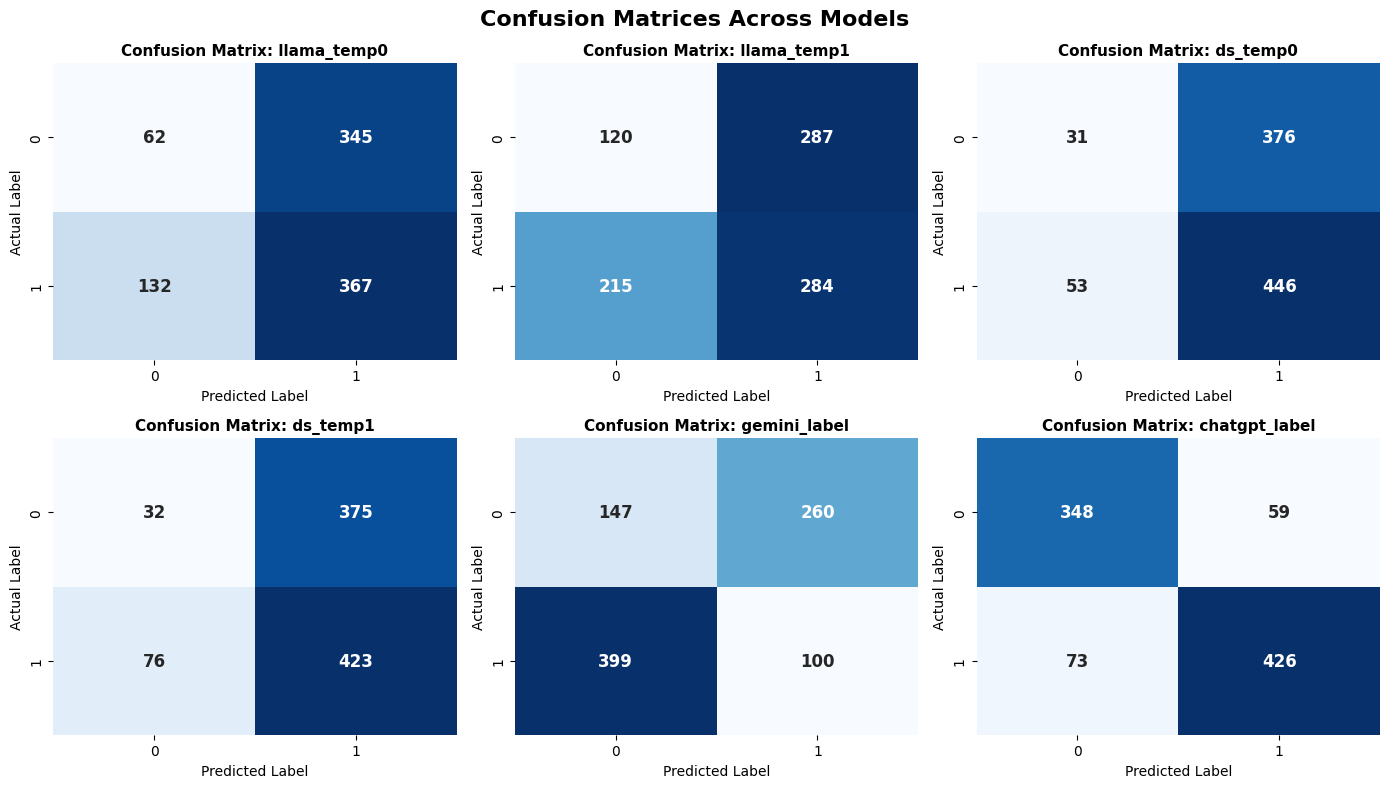

In [16]:

# Create a 2x3 subplot grid
figure, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

# Generate Confusion Matrix heatmap for each model
for index, model in enumerate(model_result_columns):
    ConfusionMatrix = confusion_matrix(data_one["label"], data_one[model])

    sns.heatmap(
        ConfusionMatrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=axes[index],
        cbar=False,
        annot_kws={"size": 12, "weight": "bold"},
    )

    axes[index].set_title(
        f"Confusion Matrix: {model}", fontsize=11, fontweight="bold"
    )
    axes[index].set_xlabel("Predicted Label", fontsize=10)
    axes[index].set_ylabel("Actual Label", fontsize=10)

plt.suptitle("Confusion Matrices Across Models", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

In [17]:
# human_labelled_column = 'label'  
sarcastic_label = 1      
literal_label = 0          

actual_label = data_one['label']

# Compute metrics for both temperatures
def get_metrics(true_label, predicted_label):
    return [
        f1_score(true_label, predicted_label, average='macro'),
        f1_score(true_label, predicted_label, pos_label=sarcastic_label, average='binary'),
        f1_score(true_label, predicted_label, pos_label=literal_label, average='binary'),
        accuracy_score(true_label, predicted_label)
    ]

metrics = ['Macro F1', 'Sarcastic F1', 'Literal F1', 'Accuracy']

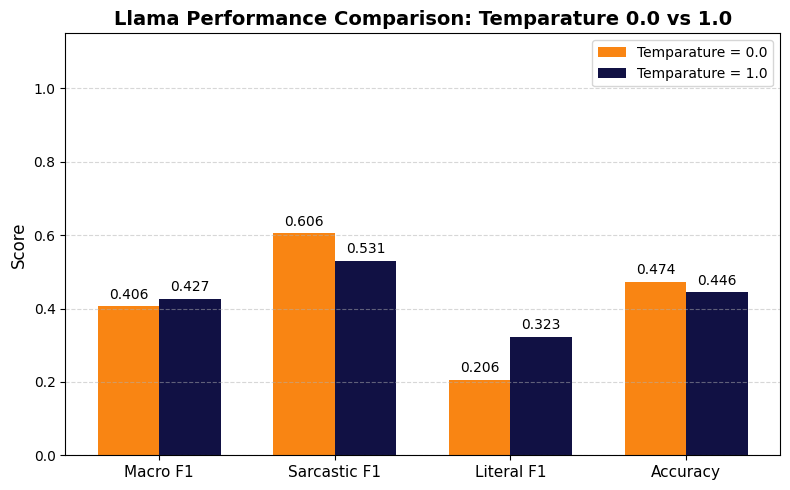

In [18]:

predicted_label_temp0 = data_one['llama_temp0']
predicted_label_temp1 = data_one['llama_temp1']


temp0_scores = get_metrics(actual_label, predicted_label_temp0)
temp1_scores = get_metrics(actual_label, predicted_label_temp1)

# Plot grouped bar chart
x_axis_position = np.arange(len(metrics))
width_of_bar = 0.35

figure, ax = plt.subplots(figsize=(8, 5))
bar1 = ax.bar(x_axis_position - width_of_bar/2, temp0_scores, width_of_bar, label='Temparature = 0.0', color='#F98513')
bar2 = ax.bar(x_axis_position + width_of_bar/2, temp1_scores, width_of_bar, label='Temparature = 1.0', color='#111144')

ax.set_ylabel('Score', fontsize=12)
ax.set_title('Llama Performance Comparison: Temparature 0.0 vs 1.0', fontsize=14, fontweight='bold')
ax.set_xticks(x_axis_position)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0, 1.15)
ax.legend(loc='upper right')
ax.grid(axis='y', linestyle='--', alpha=0.5)

# Add value labels on top of bars
ax.bar_label(bar1, padding=3, fmt='%.3f')
ax.bar_label(bar2, padding=3, fmt='%.3f')

plt.tight_layout()
plt.show()

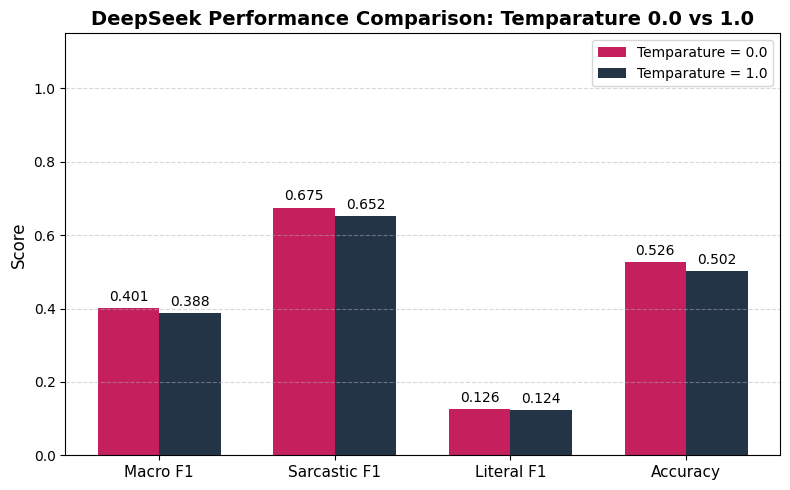

In [19]:
     
predicted_label_temp0 = data_one['ds_temp0']
predicted_label_temp1 = data_one['ds_temp1']


temp0_scores = get_metrics(actual_label, predicted_label_temp0)
temp1_scores = get_metrics(actual_label, predicted_label_temp1)

# Plot grouped bar chart
x_axis_position = np.arange(len(metrics))
width_of_bar = 0.35

figure, ax = plt.subplots(figsize=(8, 5))
bar1 = ax.bar(x_axis_position - width_of_bar/2, temp0_scores, width_of_bar, label='Temparature = 0.0', color='#C51F5D')
bar2 = ax.bar(x_axis_position + width_of_bar/2, temp1_scores, width_of_bar, label='Temparature = 1.0', color='#243447')

ax.set_ylabel('Score', fontsize=12)
ax.set_title('DeepSeek Performance Comparison: Temparature 0.0 vs 1.0', fontsize=14, fontweight='bold')
ax.set_xticks(x_axis_position)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0, 1.15)
ax.legend(loc='upper right')
ax.grid(axis='y', linestyle='--', alpha=0.5)

# Add value labels on top of bars
ax.bar_label(bar1, padding=3, fmt='%.3f')
ax.bar_label(bar2, padding=3, fmt='%.3f')

plt.tight_layout()
plt.show()